To build a 2D KS equation. Remembering that the KS equation is equivalent to du/dt = -(laplacian(u)+ biharmonic(u) + magnitude(grad(u))^2/2)
this is equivalent to du/dt = -(u_xx + u_yy + laplacian(laplacian(u)) + ((u)^2_x + (u)^2_y)/2 ). Our linear operator is laplace + biharmonic, our non-linear is the mag grad. As such I need to build matrices for the laplacian and for the directional derivatives. I will build the biharmonic by multiplying the laplacian by itself.

In [26]:
##import dependency
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.sparse as sp
from scipy.linalg import expm
from datetime import datetime
import time
from scipy.sparse.linalg import spsolve

In [27]:
##To build a 2D KS equation with periodic boundary conditions.
# Remembering that the KS equation is equivalent to du/dt = -(laplacian(u)+ biharmonic(u) + magnitude(grad(u))^2/2)
##this is equivalent to du/dt = -(u_xx + u_yy + laplacian(laplacian(u)) + (u_x)^2 + (u_y)^2/2 ). Our linear operator is laplace + biharmonic,
# our non-linear is the mag grad. As such I need to build matrices for the laplacian and for the directional derivatives.
# I will build the biharmonic by multiplying the laplacian by itself.

##building the laplacian matrix for periodic boundary conditions. which I need as a matrix.
def build_laplacian_matrix(N):
    # Create the 1D Laplacian matrix with periodic boundary conditions
    e = np.ones(N)
    L_1D = sp.diags([e, -2*e, e], [-1, 0, 1], shape=(N, N)).toarray()
    L_1D[0, -1] = 1  # Periodic boundary condition
    L_1D[-1, 0] = 1  # Periodic boundary condition
    
    # Create the 2D Laplacian matrix using Kronecker products
    I = np.eye(N)
    L_2D = np.kron(I, L_1D) + np.kron(L_1D, I)
    
    return L_2D


In [28]:
##building the biharmonic matrix by multiplying the laplacian by itself.
def build_biharmonic_matrix(N):
    L = build_laplacian_matrix(N)
    B = L @ L
    return B

In [29]:
for row in build_laplacian_matrix(6):
    print(row)

[-4.  1.  0.  0.  0.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.]
[ 1. -4.  1.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.]
[ 0.  1. -4.  1.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.]
[ 0.  0.  1. -4.  1.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.]
[ 0.  0.  0.  1. -4.  1.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.]
[ 1.  0.  0.  0.  1. -4.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.]
[ 1.  0.  0.  0.  0.  0. -4.  1.  0.  0.  0.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.

In [30]:
##print out the matrix in a way thats legible
np.set_printoptions(threshold=np.inf, linewidth=200)
for row in build_biharmonic_matrix(8):
    print(row)


[20. -8.  1.  0.  0.  0.  1. -8. -8.  2.  0.  0.  0.  0.  0.  2.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.
  0.  0.  0.  0.  0.  0.  0. -8.  2.  0.  0.  0.  0.  0.  2.]
[-8. 20. -8.  1.  0.  0.  0.  1.  2. -8.  2.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  1.  0.  0.  0.  0.  0.  0.  2. -8.  2.  0.  0.  0.  0.  0.]
[ 1. -8. 20. -8.  1.  0.  0.  0.  0.  2. -8.  2.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  1.  0.  0.  0.  0.  0.  0.  2. -8.  2.  0.  0.  0.  0.]
[ 0.  1. -8. 20. -8.  1.  0.  0.  0.  0.  2. -8.  2.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  1.  0.  0.  0.  

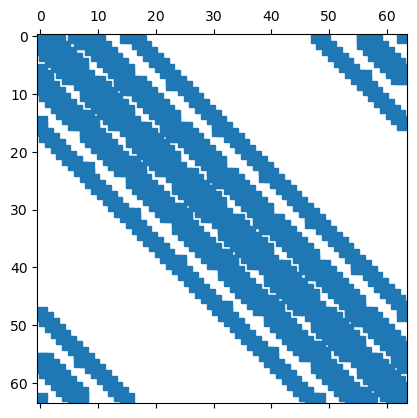

In [31]:
plt.spy(build_biharmonic_matrix(8), markersize=10)

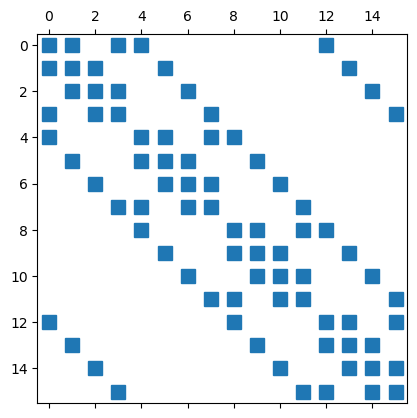

In [32]:
##matrix plot
plt.spy(build_laplacian_matrix(4), markersize=10)

In [33]:
build_laplacian_matrix(4)

array([[-4.,  1.,  0.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.],
       [ 1., -4.,  1.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.],
       [ 0.,  1., -4.,  1.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.],
       [ 1.,  0.,  1., -4.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.],
       [ 1.,  0.,  0.,  0., -4.,  1.,  0.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  1.,  0.,  0.,  1., -4.,  1.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  1.,  0.,  0.,  1., -4.,  1.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  1.,  1.,  0.,  1., -4.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  1.,  0.,  0.,  0., -4.,  1.,  0.,  1.,  1.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  1., -4.,  1.,  0.,  0.,  1.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  1., -4.,  1.,  0.,  0.,  1.,  0.],
       [ 0.,  0.,  0.

In [34]:
def x_derivative_matrix(N):
    e = np.ones(N)
    D_1D = sp.diags([-e, e], [-1, 1], shape=(N, N)).toarray()
    D_1D[0, -1] = -1
    D_1D[-1, 0] = 1

    I = np.eye(N)
    D_x = np.kron(I, D_1D)

    return D_x


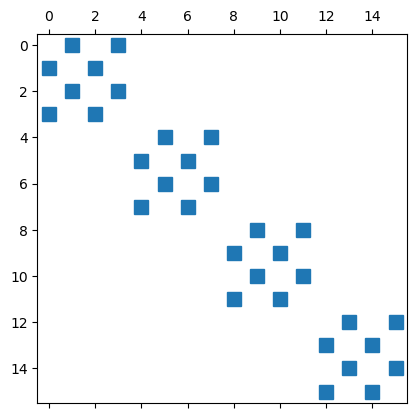

In [35]:
plt.spy(x_derivative_matrix(4), markersize=10)

In [36]:
print(x_derivative_matrix(4))

[[ 0.  1.  0. -1.  0.  0.  0. -0.  0.  0.  0. -0.  0.  0.  0. -0.]
 [-1.  0.  1.  0. -0.  0.  0.  0. -0.  0.  0.  0. -0.  0.  0.  0.]
 [ 0. -1.  0.  1.  0. -0.  0.  0.  0. -0.  0.  0.  0. -0.  0.  0.]
 [ 1.  0. -1.  0.  0.  0. -0.  0.  0.  0. -0.  0.  0.  0. -0.  0.]
 [ 0.  0.  0. -0.  0.  1.  0. -1.  0.  0.  0. -0.  0.  0.  0. -0.]
 [-0.  0.  0.  0. -1.  0.  1.  0. -0.  0.  0.  0. -0.  0.  0.  0.]
 [ 0. -0.  0.  0.  0. -1.  0.  1.  0. -0.  0.  0.  0. -0.  0.  0.]
 [ 0.  0. -0.  0.  1.  0. -1.  0.  0.  0. -0.  0.  0.  0. -0.  0.]
 [ 0.  0.  0. -0.  0.  0.  0. -0.  0.  1.  0. -1.  0.  0.  0. -0.]
 [-0.  0.  0.  0. -0.  0.  0.  0. -1.  0.  1.  0. -0.  0.  0.  0.]
 [ 0. -0.  0.  0.  0. -0.  0.  0.  0. -1.  0.  1.  0. -0.  0.  0.]
 [ 0.  0. -0.  0.  0.  0. -0.  0.  1.  0. -1.  0.  0.  0. -0.  0.]
 [ 0.  0.  0. -0.  0.  0.  0. -0.  0.  0.  0. -0.  0.  1.  0. -1.]
 [-0.  0.  0.  0. -0.  0.  0.  0. -0.  0.  0.  0. -1.  0.  1.  0.]
 [ 0. -0.  0.  0.  0. -0.  0.  0.  0. -0.  0.  0.  0. -1.  0. 

In [37]:
def y_derivative_matrix(N):
    e = np.ones(N)
    D_1D = sp.diags([-e, e], [-1, 1], shape=(N, N)).toarray()
    D_1D[0, -1] = -1
    D_1D[-1, 0] = 1

    I = np.eye(N)
    D_y = np.kron(D_1D, I)

    return D_y

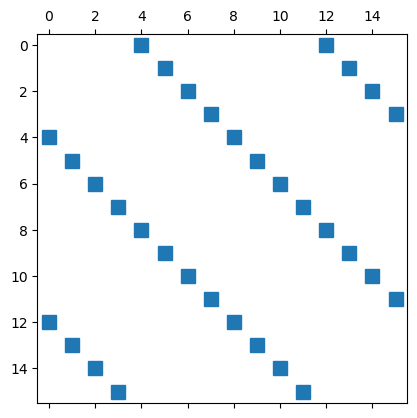

In [38]:
plt.spy(y_derivative_matrix(4), markersize=10)

In [39]:
def factorial(n):
    if n == 0:
        return 1
    else:
        return n * factorial(n-1)

In [40]:
def alpha_taylor_coefficient(n):
    return 4/factorial(n+3) - 3/factorial(n+2) + 1/factorial(n+1)
def beta_taylor_coefficient(n):
    return -2/factorial(n+3) + 1/factorial(n+2)
def gamma_taylor_coefficient(n):
    return 4/factorial(n+3) - 1/factorial(n+2)
def Q_taylor_coefficient(n):
    return 1/(2**n * factorial(n+1))

In [41]:
for i in range(10):
    print(i)

0
1
2
3
4
5
6
7
8
9


In [42]:
def taylor_series_gamma(z, order):
    A = z.copy()
    for n in range(order):
        if n == 0:
            res = gamma_taylor_coefficient(n) * np.linalg.matrix_power(z, n)
        else:
            res += gamma_taylor_coefficient(n) * A
            A = A @ z
    return res

def taylor_series_alpha(z, order):
    A = z.copy()
    res = alpha_taylor_coefficient(0) * np.linalg.matrix_power(z, 0)
    for n in range(1, order):
        res += alpha_taylor_coefficient(n) * A
        A = A @ z
    return res

def taylor_series_beta(z, order):
    A = z.copy()
    res = beta_taylor_coefficient(0) * np.linalg.matrix_power(z, 0)
    for n in range(1, order):
        res += beta_taylor_coefficient(n) * A
        A = A @ z
    return res

def taylor_series_Q(z, order):
    A = z.copy()
    res = Q_taylor_coefficient(0) * np.linalg.matrix_power(z, 0)
    for n in range(1, order):
        res += Q_taylor_coefficient(n) * A
        A = A @ z
    return res/2

In [43]:
M = np.array([[100,0],[0,300]])

In [44]:
(expm(M/2) - np.eye(2))

array([[5.18470553e+21, 0.00000000e+00],
       [0.00000000e+00, 1.39370958e+65]])

In [45]:
np.linalg.inv(M) 

array([[0.01      , 0.        ],
       [0.        , 0.00333333]])

In [46]:
np.linalg.inv(M) @ (expm(M/2) - np.eye(2))

array([[5.18470553e+19, 0.00000000e+00],
       [0.00000000e+00, 4.64569860e+62]])

In [47]:
np.linalg.inv(M) @ (
M/2
+ M@M/(2**2*factorial(2))
+ M@M@M/(2**3*factorial(3))
+ M@M@M@M/(2**4*factorial(4))
+ M@M@M@M@M/(2**5*factorial(5))
+ M@M@M@M@M@M/(2**6*factorial(6))
+ M@M@M@M@M@M@M/(2**7*factorial(7))
+ M@M@M@M@M@M@M@M/(2**8*factorial(8))
+ M@M@M@M@M@M@M@M@M/(2**9*factorial(9))
+ M@M@M@M@M@M@M@M@M@M/(2**10*factorial(10))
+ M@M@M@M@M@M@M@M@M@M@M/(2**11*factorial(11))
)

array([[ 8.64352702e+07,  0.00000000e+00],
       [ 0.00000000e+00, -1.44532996e+09]])

In [48]:
taylor_series_Q(M, 20)

array([[ 4.30410285e+08,  0.00000000e+00],
       [ 0.00000000e+00, -2.14884453e+10]])

In [49]:
def KS_FDM_2D(N, method = 'contour',ic = 'random'):
    order = 18
    time_start = time.time()
    ##Discretize the spatial domain
    x = np.linspace(0, 8*np.pi, N, endpoint=False)
    y = np.linspace(0, 8*np.pi, N, endpoint=False)
    dx = x[1] - x[0]
    if ic == 'random':
        np.random.seed(12345)
        X, Y = np.meshgrid(x, y)
        u0 = np.random.randn(N, N)  # Random normal distribution
        
        u = u0.flatten()
    else:
        ## initial condition
        ## np.cos(x/16) * (1 + np.sin(x/16))* np.cos(y/16) * (1 + np.sin(y/16))
        X, Y = np.meshgrid(x, y)
        u0 = np.cos(X/16) * (1 + np.sin(X/16))* (np.cos(Y/16) * (1 + np.sin(Y/16)))
        u = u0.flatten()
    
    print("Initial condition set up. Starting time-stepping...")
    
    
    
    # Build the linear operator (Laplacian + Biharmonic)
    L = build_laplacian_matrix(N)/(dx**2)
    B = build_biharmonic_matrix(N)/(dx**4)
    Linear_Operator =-(L + B)
    I = np.eye(N**2)
    # build non-linear operator
    x_deriv = x_derivative_matrix(N)/(2*dx)
    y_deriv = y_derivative_matrix(N)/(2*dx)
    
    print("Linear operator constructed. Computing ETD-RK4 coefficients...")
    ## ETD-RK4 coefficients
    h = 1/400
    ## for debugging I want to see what my operators look like:
    print("Linear operator (first few rows/columns):")
    print(Linear_Operator[:5, :5])
    print("Linear operator max value:", np.max(np.abs(Linear_Operator)))
    print("non-linear x derivative (first few rows/columns):")
    print(x_deriv[:5, :5])

    A = h * Linear_Operator
    E = expm(A)
    E2 = expm(A / 2)

    Z = np.zeros((N**2,N**2))

   

    print("Computing ETD-RK4 coefficients...")
    if method == 'contour':
        M = 64
    
        r = 15 * np.exp(1j *2* np.pi * (np.arange(1, M+1) - 0.5) / M)
        
        f1 = Z.copy()
        f2 = Z.copy()
        f3 = Z.copy()
        Q  = Z.copy()
        for j in range(M):
            print("coefficient youre on: ", j)
            z = r[j]
            
            IA_to_invert = z * I - A
            ##matrix is sparse, store in a way that allows for efficient inversion
            
            
            
            zIA = np.linalg.inv(IA_to_invert)

            Q  = Q + h * zIA * (np.exp(z/2) - 1)
            f1 = f1 + h * zIA * (-4 - z + np.exp(z)*(4 - 3*z + z**2)) / z**2
            f2 = f2 + h * zIA * (2 + z + np.exp(z)*(z - 2)) / z**2
            f3 = f3 + h * zIA * (-4 - 3*z - z**2 + np.exp(z)*(4 - z)) / z**2
        
        
        Q  = np.real(Q)/M
        f1 = np.real(f1)/M
        f2 = np.real(f2)/M
        f3 = np.real(f3)/M
    
    if method == 'series':
        f1 = h*taylor_series_alpha(A, order)
        print("alpha done")
        f2 = h*taylor_series_beta(A, order)
        print("beta done")
        f3 = h*taylor_series_gamma(A, order)
        print("gamma done")
        Q =  h*taylor_series_Q(A, order)
        print("Q done")
    print("ETD-RK4 coefficients computed. Starting time-stepping...")
    print("E eigenvalues (estimation):", np.max(np.abs(np.linalg.eigvalsh(A))))
    print("Q max value:", np.max(np.abs(Q)))
    print("E2 max value:", np.max(np.abs(E2)))
    print("Any NaNs in Q?", np.any(np.isnan(Q)))
    
    
    
    tt = np.array([0.0])
    

    tmax = 32
    nmax = round(tmax / h)
    nplt = int(np.floor((nmax/100)))
    snapshots = []
    
    for n in range(nmax):
        
        # if n == 10:
        #     break
        t = n * h
        #print("step youre on: ", n)
        
        Nu = -0.5 * ((x_deriv @ (u**2)) + (y_deriv @ (u**2)))
        #print("shape of u: ", u.shape)
        #print("Max value in u", np.max(np.abs(u)))
        a = E2 @ u + Q @ Nu
        ##print("Max value in a:", np.max(np.abs(a)))

        #print("shape of a: ", a.shape)
        Na = -0.5 * ((x_deriv @ a**2) + (y_deriv @ a**2))
        b = E2 @ u + Q @ Na
        Nb = -0.5 * ((x_deriv @ b**2) + (y_deriv @ b**2))
        c = E2 @ a + Q @ (2*Nb - Nu)
        Nc = -0.5 * ((x_deriv @ c**2) + (y_deriv @ c**2))
        if np.any(np.isnan(a)) or np.any(np.isnan(b)) or np.any(np.isnan(c)):
            print(f"NaN encountered at step {n}, t={t:.6g}; stopping time-stepping.")
            break
        if np.any(np.isinf(a)) or np.any(np.isinf(b)) or np.any(np.isinf(c)):
            print(f"Inf encountered at step {n}, t={t:.6g}; stopping time-stepping.")
            break
        
        u = E @ u + f1 @ Nu + 2*f2 @ (Na + Nb) + f3 @ Nc
        if n%(10*nplt) == 0:
            print("you have completed", n/nmax)
        if n % nplt == 0:
            tt = np.append(tt, t)
            #print(f"Time: {t:.2f}")
            ##save the solution at this time step
            snapshots.append(u.copy())
    time_end = time.time()
    print(f"Total time: {time_end - time_start:.2f} seconds")
    return X, Y, snapshots, tt
    

    

Initial condition set up. Starting time-stepping...


Linear operator constructed. Computing ETD-RK4 coefficients...
Linear operator (first few rows/columns):
[[-815.05104329  329.91115077  -42.04946332   -0.           -0.        ]
 [ 329.91115077 -815.05104329  329.91115077  -42.04946332   -0.        ]
 [ -42.04946332  329.91115077 -815.05104329  329.91115077  -42.04946332]
 [  -0.          -42.04946332  329.91115077 -815.05104329  329.91115077]
 [  -0.           -0.          -42.04946332  329.91115077 -815.05104329]]
Linear operator max value: 815.0510432913024
non-linear x derivative (first few rows/columns):
[[ 0.          1.27323954  0.          0.          0.        ]
 [-1.27323954  0.          1.27323954  0.          0.        ]
 [ 0.         -1.27323954  0.          1.27323954  0.        ]
 [ 0.          0.         -1.27323954  0.          1.27323954]
 [ 0.          0.          0.         -1.27323954  0.        ]]
Computing ETD-RK4 coefficients...
coefficient youre on:  0
coefficient youre on:  1
coefficient youre on:  2
coefficie

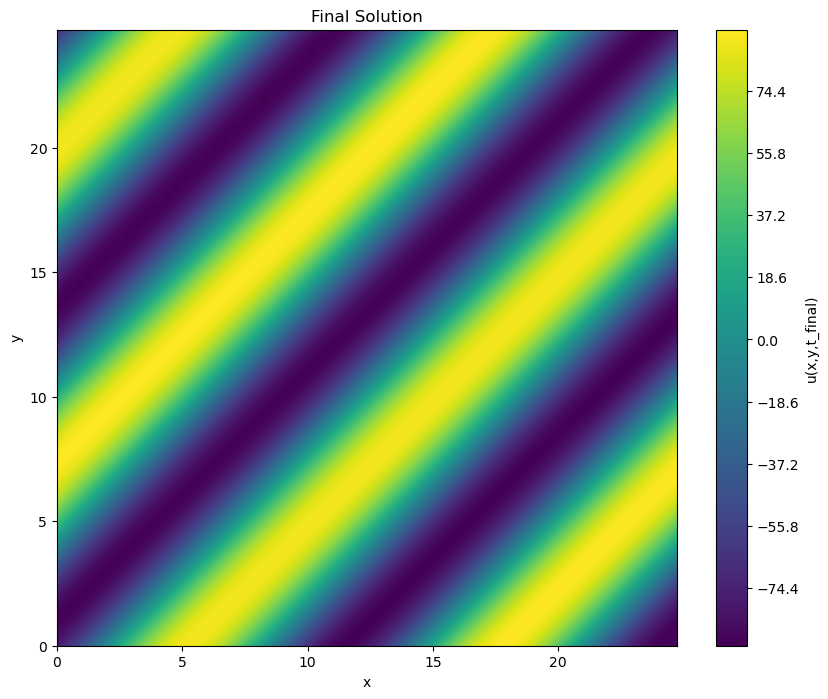

In [50]:
##compute the solution
N = 64
method = 'contour'
X, Y, snapshots, tt = KS_FDM_2D(N, method=method, ic = 'random')
##plotting final solution
plt.figure(figsize=(10, 8))
print("x shape:", X.shape)
plt.contourf(X, Y, snapshots[-1].reshape(N, N), levels=1000, cmap='viridis')
plt.colorbar(label='u(x,y,t_final)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Final Solution')
plt.show()


In [51]:
##save the final snapshot as a file
# Create filename with method, N, and tmax
final_snapshot = snapshots[-1].reshape(N, N)
method = 'contour'
tmax = 16

filename = f'2D_KS_FDM_snapshots/KS_method={method}_N={N}_tmax={tmax}.npy'
np.save(filename, final_snapshot)
print(f"Saved to {filename}")


Saved to 2D_KS_FDM_snapshots/KS_method=contour_N=64_tmax=16.npy


In [53]:
##create a gif of the solution evolving over time
from matplotlib.animation import FuncAnimation
N = 64
x = np.linspace(0, 16*np.pi, N, endpoint=False)
y = np.linspace(0, 16*np.pi, N, endpoint=False)
X, Y = np.meshgrid(x, y)

from matplotlib.animation import PillowWriter

fig, ax = plt.subplots(figsize=(10, 8))
ax_bar = fig.add_axes([0.85, 0.1, 0.1, 0.8])  



def animate(frame):
    ax.clear()
    u_2d = snapshots[frame].reshape(N, N)
    ax.contourf(X, Y, u_2d, levels=100, cmap='viridis')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f't = {tt[frame]:.4f}')
    u_min = np.min(u_2d)
    u_max = np.max(u_2d)

    # Clear the bar chart and update it with the new values
    ax.text(0.05, 0.95, f'Min: {u_min:.4f}', transform=ax.transAxes, fontsize=12,
            verticalalignment='top', horizontalalignment='left', color='white')
    ax.text(0.05, 0.90, f'Max: {u_max:.4f}', transform=ax.transAxes, fontsize=12,
            verticalalignment='top', horizontalalignment='left', color='white')

    
    
    
anim = FuncAnimation(fig, animate, frames=len(snapshots), interval=100)
writer = PillowWriter(fps=10)
anim.save('ks_solution.gif', writer=writer)
plt.close()
print("Saved as ks_solution.gif")

Saved as ks_solution.gif


In [ ]:
import random as rnd

In [ ]:
def KS_FDM_2D_ric(N, method = 'contour', seed=None):
    order = 18
    time_start = time.time()
    ##Discretize the spatial domain
    x = np.linspace(0, 2*np.pi, N, endpoint=False)
    y = np.linspace(0, 2*np.pi, N, endpoint=False)
    dx = x[1] - x[0]
    
    ## Random initial conditions
    np.random.seed(12345)
    X, Y = np.meshgrid(x, y)
    u0 = np.random.randn(N, N)  # Random normal distribution
    
    u = u0.flatten()
    
    
    print("Initial condition set up. Starting time-stepping...")
    
    
    
    # Build the linear operator (Laplacian + Biharmonic)
    L = build_laplacian_matrix(N)/(dx**2)
    B = build_biharmonic_matrix(N)/(dx**4)
    Linear_Operator =-(L + B)
    I = np.eye(N**2)
    # build non-linear operator
    x_deriv = x_derivative_matrix(N)/(2*dx)
    y_deriv = y_derivative_matrix(N)/(2*dx)
    
    print("Linear operator constructed. Computing ETD-RK4 coefficients...")
    ## ETD-RK4 coefficients
    h = 1/4000
    ## for debugging I want to see what my operators look like:
    print("Linear operator (first few rows/columns):")
    print(Linear_Operator[:5, :5])
    print("Linear operator max value:", np.max(np.abs(Linear_Operator)))
    print("non-linear x derivative (first few rows/columns):")
    print(x_deriv[:5, :5])

    A = h * Linear_Operator
    E = expm(A)
    E2 = expm(A / 2)

    Z = np.zeros((N**2,N**2))

   

    print("Computing ETD-RK4 coefficients...")
    if method == 'contour':
        M = 64
    
        r = 15 * np.exp(1j *2* np.pi * (np.arange(1, M+1) - 0.5) / M)
        
        f1 = Z.copy()
        f2 = Z.copy()
        f3 = Z.copy()
        Q  = Z.copy()
        for j in range(M):
            print("coefficient youre on: ", j)
            z = r[j]
            
            IA_to_invert = z * I - A
            ##matrix is sparse, store in a way that allows for efficient inversion
            
            
            
            zIA = np.linalg.inv(IA_to_invert)

            Q  = Q + h * zIA * (np.exp(z/2) - 1)
            f1 = f1 + h * zIA * (-4 - z + np.exp(z)*(4 - 3*z + z**2)) / z**2
            f2 = f2 + h * zIA * (2 + z + np.exp(z)*(z - 2)) / z**2
            f3 = f3 + h * zIA * (-4 - 3*z - z**2 + np.exp(z)*(4 - z)) / z**2
        
        
        Q  = np.real(Q)/M
        f1 = np.real(f1)/M
        f2 = np.real(f2)/M
        f3 = np.real(f3)/M
    
    # if method == 'series':
    #     f1 = h*taylor_series_alpha(A, order)
    #     print("alpha done")
    #     f2 = h*taylor_series_beta(A, order)
    #     print("beta done")
    #     f3 = h*taylor_series_gamma(A, order)
    #     print("gamma done")
    #     Q =  h*taylor_series_Q(A, order)
    #     print("Q done")
    # print("ETD-RK4 coefficients computed. Starting time-stepping...")
    print("E eigenvalues (estimation):", np.max(np.abs(np.linalg.eigvalsh(A))))
    print("Q max value:", np.max(np.abs(Q)))
    print("E2 max value:", np.max(np.abs(E2)))
    print("Any NaNs in Q?", np.any(np.isnan(Q)))
    
    
    
    tt = np.array([0.0])
    

    tmax = 10
    nmax = round(tmax / h)
    nplt = int(np.floor((nmax/100)))
    snapshots = []
    
    for n in range(nmax):
        
        # if n == 10:
        #     break
        t = n * h
        #print("step youre on: ", n)
        
        Nu = -0.5 * ((x_deriv @ (u**2)) + (y_deriv @ (u**2)))
        #print("shape of u: ", u.shape)
        #print("Max value in u", np.max(np.abs(u)))
        a = E2 @ u + Q @ Nu
        #print("Max value in a:", np.max(np.abs(a)))
        if np.max(np.abs(a)) > 1e100:
            print("WARNING: a is explosively large!")
        #print("shape of a: ", a.shape)
        Na = -0.5 * ((x_deriv @ (a**2)) + (y_deriv @ (a**2)))
        b = E2 @ u + Q @ Na
        Nb = -0.5 * ((x_deriv @ (b**2)) + (y_deriv @ (b**2)))
        c = E2 @ a + Q @ (2*Nb - Nu)
        Nc = -0.5 * ((x_deriv @ (c**2)) + (y_deriv @ (c**2)))
        ## if a b or c contain NaN break
        if np.any(np.isnan(a)) or np.any(np.isnan(b)) or np.any(np.isnan(c)):
            print(f"NaN encountered at step {n}, t={t:.6g}; stopping time-stepping.")
            break
        if np.any(np.isinf(a)) or np.any(np.isinf(b)) or np.any(np.isinf(c)):
            print(f"Inf encountered at step {n}, t={t:.6g}; stopping time-stepping.")
            break
        
        
        u = E @ u + f1 @ Nu + 2*f2 @ (Na + Nb) + f3 @ Nc
        
        if n % nplt == 0:
            tt = np.append(tt, t)
            #print(f"Time: {t:.2f}")
            ##save the solution at this time step
            snapshots.append(u.copy())
    time_end = time.time()
    print(f"Total time: {time_end - time_start:.2f} seconds")
    return X, Y, snapshots, tt

Initial condition set up. Starting time-stepping...
Linear operator constructed. Computing ETD-RK4 coefficients...
Linear operator (first few rows/columns):
[[-13352.07536881   5356.39308133   -672.79141304     -0.             -0.        ]
 [  5356.39308133 -13352.07536881   5356.39308133   -672.79141304     -0.        ]
 [  -672.79141304   5356.39308133 -13352.07536881   5356.39308133   -672.79141304]
 [    -0.           -672.79141304   5356.39308133 -13352.07536881   5356.39308133]
 [    -0.             -0.           -672.79141304   5356.39308133 -13352.07536881]]
Linear operator max value: 13352.075368810101
non-linear x derivative (first few rows/columns):
[[ 0.          2.54647909  0.          0.          0.        ]
 [-2.54647909  0.          2.54647909  0.          0.        ]
 [ 0.         -2.54647909  0.          2.54647909  0.        ]
 [ 0.          0.         -2.54647909  0.          2.54647909]
 [ 0.          0.          0.         -2.54647909  0.        ]]
Computing ETD-R

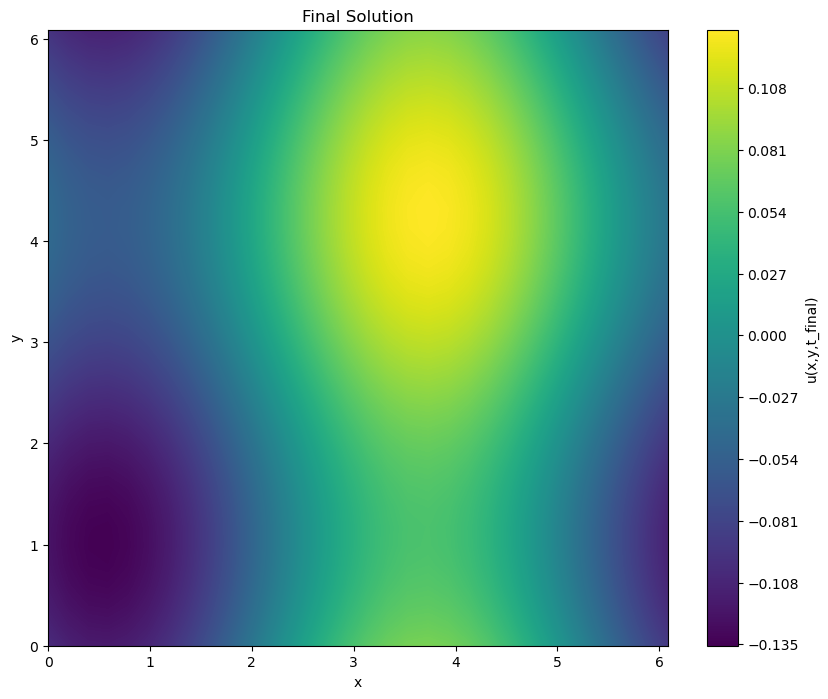

In [ ]:
##compute the solution
N = 32
X, Y, snapshots, tt = KS_FDM_2D_ric(N, method='contour')
##plotting final solution
plt.figure(figsize=(10, 8))
print("x shape:", X.shape)
plt.contourf(X, Y, snapshots[-1].reshape(N, N), levels=1000, cmap='viridis')
plt.colorbar(label='u(x,y,t_final)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Final Solution')
plt.show()

In [ ]:
from matplotlib.animation import FuncAnimation
N = 32
x = np.linspace(0, 2*np.pi, N, endpoint=False)
y = np.linspace(0, 2*np.pi, N, endpoint=False)
X, Y = np.meshgrid(x, y)

from matplotlib.animation import PillowWriter

fig, ax = plt.subplots(figsize=(10, 8))
N = X.shape[0]
def animate(frame):
    ax.clear()
    u_2d = snapshots[frame].reshape(N, N)
    ax.contourf(X, Y, u_2d, levels=100, cmap='viridis')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f't = {tt[frame]:.4f}')

anim = FuncAnimation(fig, animate, frames=len(snapshots), interval=100)
writer = PillowWriter(fps=20)
anim.save('ks_solution_random.gif', writer=writer)
plt.close()
print("Saved as ks_solution_random.gif")

Saved as ks_solution_random.gif


In [ ]:
N = 100
x = np.linspace(0, 16*np.pi, N, endpoint=False)
y = np.linspace(0, 16*np.pi, N, endpoint=False)
dx = x[1] - x[0]

## initial condition
## np.cos(x/16) * (1 + np.sin(x/16))* np.cos(y/16) * (1 + np.sin(y/16))
X, Y = np.meshgrid(x, y)
u0 = (np.cos(X/16) * (1 + np.sin(X/16)))* (np.cos(Y/16) * (1 + np.sin(Y/16)))




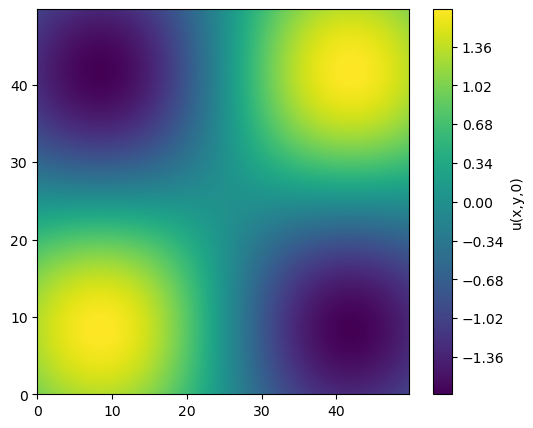

In [ ]:
##plotting the initial condition
plt.figure(figsize=(6,5))
plt.contourf(X, Y, u0, levels=1000, cmap='viridis')
plt.colorbar(label='u(x,y,0)')
